# Review of Statistics and Probability I
**HS 821 · Lecture 2 · Topics in Time Series Econometrics**
**Sunil Paul** · 5 August 2026 · R 4.5

These notes review the probability and statistical concepts used throughout time-series econometrics. The emphasis is on random variables, dependence, sampling, likelihood-based estimation, and the distinction between frequentist and Bayesian inference.


## Definitions
### Sample space, outcomes, and events

A **sample space**, denoted by $S$, is the set of all possible outcomes of a random experiment.

An **outcome** is one element $s\in S$. An **event** is a subset $A\subseteq S$.
**Example.** Suppose $M$ is the number of times an internet connection fails during a lecture. A possible sample space is

$
S=\{0,1,2,3,4,\ldots\}.
$

The statement “the connection fails at most once” describes the event

$
A=\{0,1\}.
$

**Probability ($P$)**  
Captures the idea of "chance". The probability of an event $A$ is denoted $P(A)$.  

### Kolmogorov's three axioms
1. **Non-negativity:** $P(A)\ge 0$ for any $A\subseteq S$.
2. **Normalization:** $P(S)=1$.
3. **Additivity:** if $A\cap B=\varnothing$ (disjoint), then $P(A\cup B)=P(A)+P(B)$.

**General addition rule** (events need not be disjoint):
$$P(A\cup B)=P(A)+P(B)-P(A\cap B)$$
where $P(A\cap B)$ is the **joint probability**. If $A,B$ are disjoint, $P(A\cap B)=0$ and this reduces to Axiom 3.

## Conditional probability and Bayes' theorem

The conditional probability of $A$, given that $B$ has occurred, is

$$
P(A\mid B)=\frac{P(A\cap B)}{P(B)}, \qquad P(B)>0.
$$

**Example.** Suppose 30% of students play football and 10% play both football and cricket:

$$
P(F)=0.30,\qquad P(F\cap C)=0.10.
$$

The probability that a football player also plays cricket is

$$
P(C\mid F)=\frac{P(C\cap F)}{P(F)}
=\frac{0.10}{0.30}
=\frac{1}{3}.
$$

### Law of total probability

If $B_1,\ldots,B_k$ are mutually exclusive and exhaustive events, then

$
P(A)=\sum_{i=1}^{k}P(A\mid B_i)P(B_i).
$

### Bayes' theorem

$$
P(B_j\mid A)
=
\frac{P(A\mid B_j)P(B_j)}
{\sum_{i=1}^{k}P(A\mid B_i)P(B_i)}.
$$

In this expression:

- $P(B_j)$ is the **prior probability**;
- $P(A\mid B_j)$ is the probability of the evidence under $B_j$;
- $P(B_j\mid A)$ is the **updated** or posterior probability.

The use of the word *likelihood* in statistical estimation will be defined more precisely later.

#### Example (Medical Test):

- $P(D)$: Probability a patient has the disease = 0.01.  
- $P(\text{Positive} \mid D)$: Test is positive if disease is present = 0.99.  
- $P(\text{Positive} \mid \neg D)$: Test is positive if disease is absent = 0.05.

We want $P(D \mid \text{Positive})$.

First, find $P(\text{Positive})$:
$$
P(\text{Positive}) = P(\text{Positive} \mid D)P(D) + P(\text{Positive} \mid \neg D)P(\neg D)
$$
$$
= 0.99(0.01) + 0.05(0.99) = 0.0099 + 0.0495 = 0.0594
$$

Then, apply Bayes’ theorem:
$$
P(D \mid \text{Positive}) = \frac{0.99 \cdot 0.01}{0.0594} \approx 0.1667
$$

**Interpretation:**  
Even with a highly accurate test, the probability of having the disease given a positive result is only ~16.7%, due to the low base rate ($P(D)$).

### Example 2: Contact tracing
Of 59 traced patients: 44 knew their infection source ($A$), 15 did not ($A'$):
$$P(A)=\tfrac{44}{59}\approx 0.75,\qquad P(A')=\tfrac{15}{59}\approx 0.25.$$
Self-quarantine ($Q$): 43 of the 44 with a known source quarantined, and 6 of the 15 with unknown source did **not**:
$$P(Q\mid A)=\tfrac{43}{44}\approx 0.98,\qquad P(Q\mid A')=1-\tfrac{6}{15}=0.6.$$

**Question:** given a patient quarantined, what is the chance their source was unknown, $P(A'\mid Q)$?

$$P(Q)=P(Q\mid A)P(A)+P(Q\mid A')P(A')=\tfrac{43}{59}+\tfrac{9}{59}=\tfrac{52}{59}\approx 0.881$$
$$\boxed{P(A'\mid Q)=\frac{P(Q\mid A')P(A')}{P(Q)}=\frac{9/59}{52/59}=\frac{9}{52}\approx 0.173}$$

### Exercise 1: Credit risk

A bank lends to two types of borrowers:

$$
P(L)=0.70,\qquad P(H)=0.30,
$$

where $L$ denotes low risk and $H$ denotes high risk. Their default probabilities are

$$
P(D\mid L)=0.02,\qquad P(D\mid H)=0.10.
$$

**Tasks**
1. Draw the full probability tree (first split by borrower type, then by default/no-default).
2. Compute the overall default probability $P(D)$.
3. Using Bayes’ theorem, find the posterior probability that a defaulter is high-risk: $P(H\mid D)$.


#### Exercise 2: Market Research (Product Returns)

A firm sells in two regions:
- Urban market share $P(U)=0.60$; return rate $P(R\mid U)=0.05$.
- Rural market share $P(Ru)=0.40$; return rate $P(R\mid Ru)=0.12$.

**Tasks**
1. Draw the full probability tree (first split by region, then by return/no-return).
2. Compute the overall return probability $P(R)$.
3. Using Bayes’ theorem, find the probability a returned product came from the rural market: $P(Ru\mid R)$.

#### Exercise 3: Monetary Policy Forecast

Historically, the central bank raises rates with probability $P(H)=0.30$ (no hike $H'$ with $0.70$.  
Analyst A’s forecasting performance:
- $P(\text{Predict Hike}\mid H)=0.80$.
- $P(\text{Predict Hike}\mid H')=0.20$.

**Tasks**
1. Draw the full probability tree (first split by true outcome $H$ vs. $H'$, then by Analyst A’s prediction).
2. Compute the overall probability that Analyst A predicts a hike.
3. Using Bayes’ theorem, compute $P(H\mid \text{Predict Hike})$.

## Random variables and distributions

A **random variable** is a numerical summary of a random outcome (e.g. the number of connection failures $\in\{0,1,2,3,4\}$).

- **Discrete** RV — takes countably many values; each occurs with some probability.
- **Continuous** RV — takes a continuum of values (e.g. tomorrow's temperature).

The **probability distribution** of a discrete RV lists its values and their probabilities. The **cumulative distribution function (CDF)** gives $\Pr(Y\le y)$.

<center><b>Probability of your network connection failing $M$ times</b></center>

| Outcome (failures) | 0 | 1 | 2 | 3 | 4 |
|---|---|---|---|---|---|
| **pmf** $\Pr(M=m)$ | 0.80 | 0.10 | 0.06 | 0.03 | 0.01 |
| **CDF** $\Pr(M\le m)$ | 0.80 | 0.90 | 0.96 | 0.99 | 1.00 |

For a continuous RV a value-by-value list is not possible; probability is described by a **probability density function (pdf)**, and $\Pr(a\le Y\le b)=\int_a^b f(y)\,dy$.

## Measures of the shape of a distribution

### Expected value (mean)
Long-run average over repeated trials.
$$E[Y]=\sum_i y_i p_i=\mu \quad(\text{discrete}),\qquad E[Y]=\int_{-\infty}^{\infty} y\,f(y)\,dy=\mu \quad(\text{continuous})$$
**Properties:** $E[X+Y]=E[X]+E[Y]$, and $E[aX+b]=aE[X]+b$.

### Variance and covariance
$$\mathrm{Var}(Y)=E[(Y-\mu)^2]=\sigma^2 = E[Y^2]-(E[Y])^2$$
**Properties:** $\mathrm{Var}(b)=0$; $\ \mathrm{Var}(aX+b)=a^2\mathrm{Var}(X)$; $\ \mathrm{Var}(X+Y)=\mathrm{Var}(X)+\mathrm{Var}(Y)+2\,\mathrm{Cov}(X,Y)$;
$$\mathrm{Cov}(X,Y)=E[(X-E X)(Y-E Y)]=E[XY]-E[X]E[Y].$$

### Moments
- Raw $r$-th moment: $\mu'_r=E[Y^r]$.
- Central $r$-th moment: $\mu_r=E[(Y-\mu)^r]$.
- Standardized $r$-th moment: $\gamma_r=\mu_r/\sigma^r$ $(\sigma>0)$.



### Skewness and kurtosis
$$\text{Skew}(Y)=\gamma_3=\frac{\mu_3}{\sigma^3},\qquad \beta_2=\frac{\mu_4}{\sigma^4},\qquad \text{Excess kurtosis}=\beta_2-3.$$
Skewness measures asymmetry; excess kurtosis measures heavy tails relative to the normal (which has $\beta_2=3$).

## 5. Joint, marginal and conditional distributions

We use the following binary random variables throughout: $X=1$ if the day is very cold and $X=0$ otherwise; $Y=1$ if it rains and $Y=0$ otherwise..

<center><b>Joint distribution of $X$ and $Y$</b></center>

|  | Very cold ($X=1$) | Not very cold ($X=0$) | **Total** |
|---|---|---|---|
| **Rain ($Y=1$)** | 0.15 | 0.07 | **0.22** |
| **No rain ($Y=0$)** | 0.15 | 0.63 | **0.78** |
| **Total** | **0.30** | **0.70** | **1.00** |

**Marginal distribution** — sum the joint over the other variable:
$$\Pr(Y=y)=\sum_i \Pr(X=x_i,Y=y),\qquad \Pr(Y=1)=0.15+0.07=0.22.$$

**Conditional distribution** — distribution of $Y$ given $X$ takes a value:
$$\Pr(Y=y\mid X=x)=\frac{\Pr(Y=y,X=x)}{\Pr(X=x)},\qquad \Pr(Y=1\mid X=1)=\frac{0.15}{0.30}=0.5.$$

**Conditional expectation:**
$$E(Y\mid X=x)=\sum_i y_i\,\Pr(Y=y_i\mid X=x),\qquad E(Y\mid X=1)=1(0.5)+0(0.5)=0.5.$$

**Law of iterated expectations** — the unconditional mean is the average of the conditional means:
$$E[Y]=E\big[\,E(Y\mid X)\,\big]=\sum_x E(Y\mid X=x)\,\Pr(X=x).$$

> In forecasting, $E(Y\mid X)$ is the **best predictor of $Y$ given $X$** in the mean-squared-error sense — the reason conditional expectations are central to time series.

### Independence, covariance and correlation

**Independence:** $X,Y$ are independent if the conditional distribution of $Y$ does not depend on $X$,
$$\Pr(Y=y\mid X=x)=\Pr(Y=y)\ \Longrightarrow\ \Pr(X=x,Y=y)=\Pr(X=x)\Pr(Y=y).$$

**Mean independence:** $E(Y\mid X)=E(Y)$ for all $X$.

**Covariance** measures how $X$ and $Y$ move together:
$$\mathrm{Cov}(X,Y)=\sum_{i}\sum_{j}(x_j-\mu_X)(y_i-\mu_Y)\,\Pr(X=x_j,Y=y_i).$$

For the table above ($\mu_X=0.30$, $\mu_Y=0.22$):
$$\mathrm{Cov}(X,Y)=(0.7)(0.78)(0.15)+(0.7)(-0.22)(0.15)+(-0.3)(0.78)(0.07)+(-0.3)(-0.22)(0.63)=0.084.$$

**Correlation** is the unit-free version:
$$\mathrm{Corr}(X,Y)=\frac{\mathrm{Cov}(X,Y)}{\sqrt{\mathrm{Var}(X)\mathrm{Var}(Y)}}\in[-1,1].$$

**Key logical points**
- Independent $\Rightarrow$ uncorrelated, and $\Rightarrow$ mean independent.
- Mean independent $\Rightarrow$ uncorrelated.
- **Uncorrelated does *not* imply mean independence or independence** — correlation only captures *linear* co-movement. This matters for nonlinear time-series models (e.g. GARCH), where returns can be uncorrelated yet dependent.

#### R exercise 2: zero correlation does not imply independence

Generate $X\sim N(0,1)$ and

$$
Y=X^2+u,\qquad u\sim N(0,0.2^2).
$$

The relationship is nonlinear and therefore may not be captured by correlation.

[1] -0.008960535

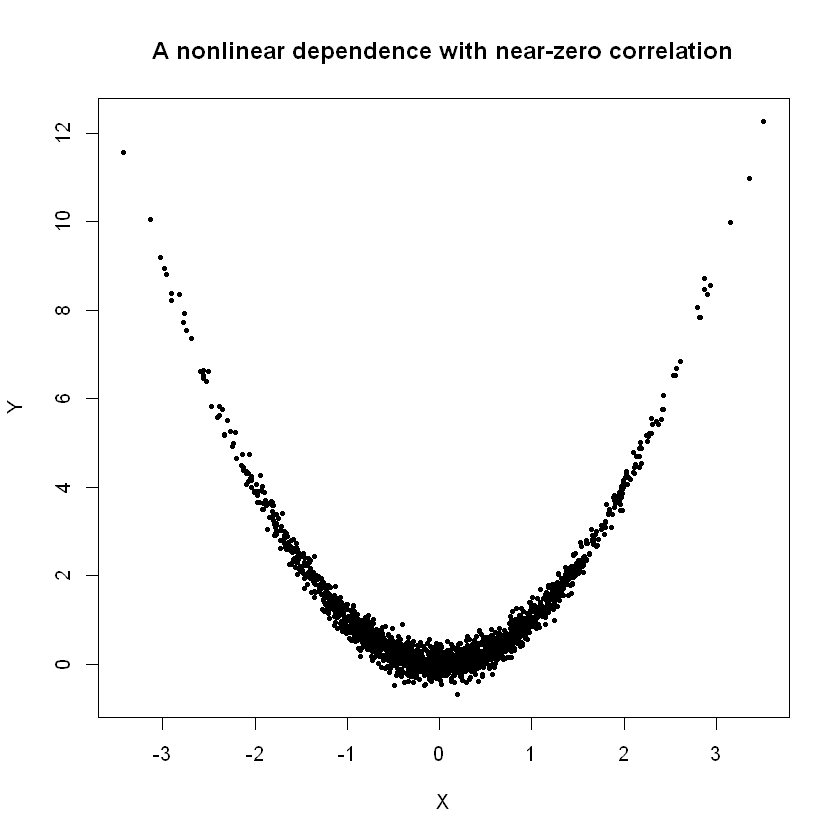

In [3]:
set.seed(821)

n <- 2000
x <- rnorm(n)
u <- rnorm(n, mean = 0, sd = 0.2)
y <- x^2 + u

cor(x, y)
plot(
  x, y,
  pch = 16,
  cex = 0.5,
  xlab = "X",
  ylab = "Y",
  main = "A nonlinear dependence with near-zero correlation")

Population, sample, and sampling distributions

A **population** is the collection of possible observations described by a probability model. A numerical feature of the population, such as $\mu$, $\sigma^2$, or $\rho$, is a **parameter**.

A **sample** is the observed data:

$$
Y_1,Y_2,\ldots,Y_n.
$$

A **statistic** is a function of the sample that does not contain unknown parameters. An **estimator** is a statistic used to estimate a parameter. Once evaluated using observed data, it produces an **estimate**.

For example,

$$
\bar Y=\frac{1}{n}\sum_{i=1}^n Y_i
$$

is an estimator of the population mean $\mu$.

### Random sampling and iid observations

A random sample is commonly assumed to be **independent and identically distributed**:

$$
Y_1,\ldots,Y_n\overset{iid}{\sim}f(y\mid\theta).
$$

The iid assumption means that all observations have the same marginal distribution and are mutually independent. Time-series observations generally violate the independence part of this assumption.

### Sampling distribution and standard error

Because an estimator is a function of random data, it has a probability distribution across repeated samples. This is its **sampling distribution**.

The standard deviation of an estimator's sampling distribution is its **standard error**.

### Law of large numbers and Central limit theorem


For an i.i.d. sample $Y_1,\dots,Y_n$ with mean $\mu$ and variance $\sigma^2$, define the sample mean $\bar Y_n=\frac1n\sum_{i=1}^n Y_i$.

**Law of Large Numbers (LLN).** $\bar Y_n \xrightarrow{p} \mu$ as $n\to\infty$: averages converge to the true mean. This is why estimators can be **consistent**.

**Central Limit Theorem (CLT).** Regardless of the shape of the underlying distribution,
$$\sqrt{n}\,\frac{\bar Y_n-\mu}{\sigma}\ \xrightarrow{d}\ N(0,1).$$
This is why $t$-, $\chi^2$- and $F$-based inference works even for non-normal data, and why the normal distribution is everywhere.

> **Time-series caveat:** the classical LLN/CLT assume independence. Time-series data are *dependent*, so we rely on their generalizations for **stationary, weakly dependent (ergodic)** processes.

### A practical example: estimating average delivery time

Suppose a food-delivery company wants to estimate the average delivery time in a city.

The **population** consists of all possible deliveries made under similar operating conditions. The unknown population mean delivery time, $\mu$, is a **parameter**.

Because observing every delivery is impractical, the company records a random **sample** of ($n=30$) deliveries:

$$
Y_1,Y_2,\ldots,Y_{30}.
$$

The sample mean,

$$
\bar Y=\frac{1}{30}\sum_{i=1}^{30}Y_i,
$$

is an **estimator** of $\mu$. Its observed value is an **estimate**.

A different sample of 30 deliveries would produce a different sample mean. The distribution of sample means obtained from repeatedly drawing samples of size 30 is the **sampling distribution** of $\bar Y$. Its standard deviation is the **standard error**.

Delivery times are usually right-skewed: most deliveries are completed reasonably quickly, but a few take much longer because of traffic, weather, or restaurant delays. Nevertheless:

* the **Law of Large Numbers** implies that the sample mean approaches the true average delivery time as the sample size increases;
* the **Central Limit Theorem** implies that the distribution of sample means becomes approximately normal, even though individual delivery times are not normally distributed.

The iid assumption would be questionable if deliveries were recorded consecutively. Deliveries during the same rush hour or rainstorm may be correlated. This illustrates why time-series data require methods that allow for dependence.


### Step 1: Construct a population of delivery times

In practice, the company cannot observe every possible delivery. For this simulation, however, we construct a large artificial population so that the population characteristics are known.

Delivery times are generated from a gamma distribution. This is reasonable because delivery times must be positive and are often right-skewed: most deliveries take a moderate amount of time, while a few take considerably longer.

In [10]:
set.seed(821)

# Size of the simulated population
N <- 100000

# Parameters of the gamma distribution
shape <- 4
scale <- 5

# Construct the population
population <- rgamma(
  N,
  shape = shape,
  scale = scale
)

# Theoretical population parameters
mu <- shape * scale
sigma <- sqrt(shape * scale^2)

# Characteristics of the simulated population
population_mean <- mean(population)
population_sd <- sd(population)
population_variance <- var(population)

round(
  c(
    theoretical_mean = mu,
    simulated_mean = population_mean,
    theoretical_sd = sigma,
    simulated_sd = population_sd
  ),
  2
)

theoretical_mean   simulated_mean   theoretical_sd     simulated_sd 
           20.00            20.01            10.00            10.00

The theoretical mean delivery time is $4\times5=20$ minutes, while the theoretical standard deviation is $10$ minutes. The simulated values should be close to these theoretical values because the population is very large.

In a real empirical study, these population parameters would be unknown. They are visible here only because we constructed the population ourselves.

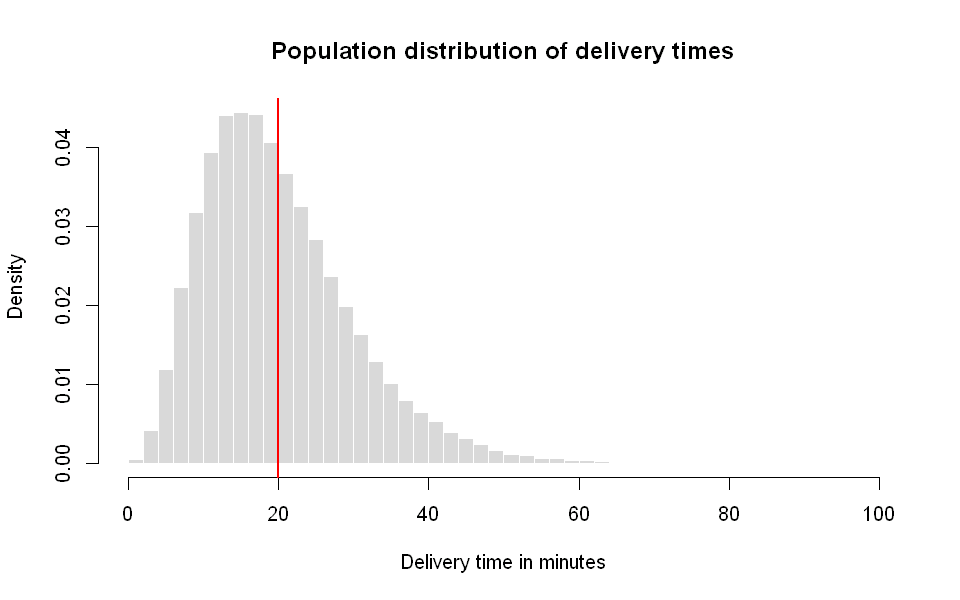

In [11]:
options(repr.plot.width = 8, repr.plot.height = 5)

hist(
  population,
  breaks = 60,
  probability = TRUE,
  main = "Population distribution of delivery times",
  xlab = "Delivery time in minutes",
  col = "grey85",
  border = "white"
)

abline(v = population_mean, col = "red", lwd = 2)

The population distribution is visibly right-skewed. The vertical line shows the population mean. We will now examine whether averages calculated from random samples have the same shape and variability.

### Step 2: Draw one random sample

Suppose the company records the delivery times of only $n=30$ randomly selected deliveries. The sample mean is then used to estimate the unknown population mean.

In [12]:
set.seed(123)

n <- 30

sample_delivery_times <- sample(
  population,
  size = n,
  replace = FALSE
)

sample_mean <- mean(sample_delivery_times)

round(sample_mean, 2)

[1] 21.81

The sample mean will generally not be exactly equal to the population mean. The difference arises from **sampling variation**: a different random sample of 30 deliveries would usually produce a different sample mean.

Thus, one sample provides only one possible estimate of the population mean.

### Step 3: Repeat the sampling procedure

To study sampling variation, imagine repeating the study many times. Each time, we select 30 deliveries and calculate their mean.

The distribution of these repeated sample means is called the **sampling distribution of the sample mean**.

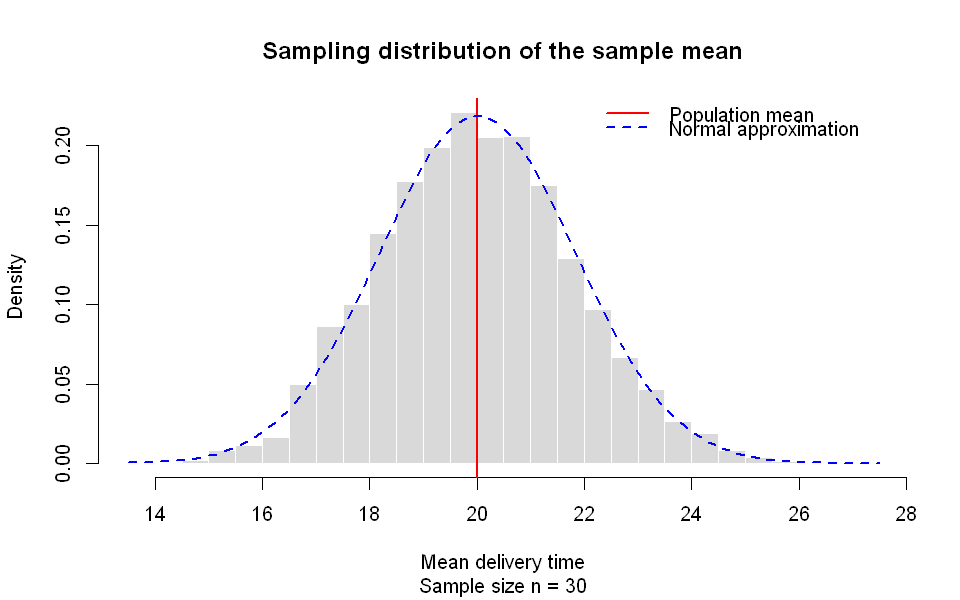

In [13]:
set.seed(456)

B <- 5000
n <- 30

sample_means_30 <- replicate(
  B,
  mean(
    sample(
      population,
      size = n,
      replace = FALSE
    )
  )
)

hist(
  sample_means_30,
  breaks = 40,
  probability = TRUE,
  main = "Sampling distribution of the sample mean",
  sub = "Sample size n = 30",
  xlab = "Mean delivery time",
  col = "grey85",
  border = "white"
)

# Population mean
abline(
  v = population_mean,
  col = "red",
  lwd = 2
)

# Normal approximation
curve(
  dnorm(
    x,
    mean = population_mean,
    sd = population_sd / sqrt(n)
  ),
  add = TRUE,
  col = "blue",
  lwd = 2,
  lty = 2
)

legend(
  "topright",
  legend = c("Population mean", "Normal approximation"),
  col = c("red", "blue"),
  lty = c(1, 2),
  lwd = 2,
  bty = "n"
)

Although individual delivery times are right-skewed, the distribution of the sample mean is approximately bell-shaped.

The sampling distribution is centred close to the population mean. Its standard deviation is the **standard error**:

$$
SE(\bar{Y})\approx\frac{\sigma}{\sqrt{n}}.
$$

For $n=30$, the standard error is approximately

$$
\frac{10}{\sqrt{30}}\approx1.83\text{ minutes}.
$$

This measures how much sample means typically differ across repeated samples.

### Step 4: Change the sample size

We now repeat the experiment using sample sizes \(n=5\), \(30\), \(100\), and \(500\).

The population and number of repetitions are held constant. Therefore, any change in the sampling distribution is caused by the change in sample size.

In [14]:
set.seed(789)

B <- 5000
sample_sizes <- c(5, 30, 100, 500)

# Generate a sampling distribution for each sample size
sampling_distributions <- lapply(
  sample_sizes,
  function(n) {
    replicate(
      B,
      mean(
        sample(
          population,
          size = n,
          replace = FALSE
        )
      )
    )
  }
)

names(sampling_distributions) <- paste0("n = ", sample_sizes)

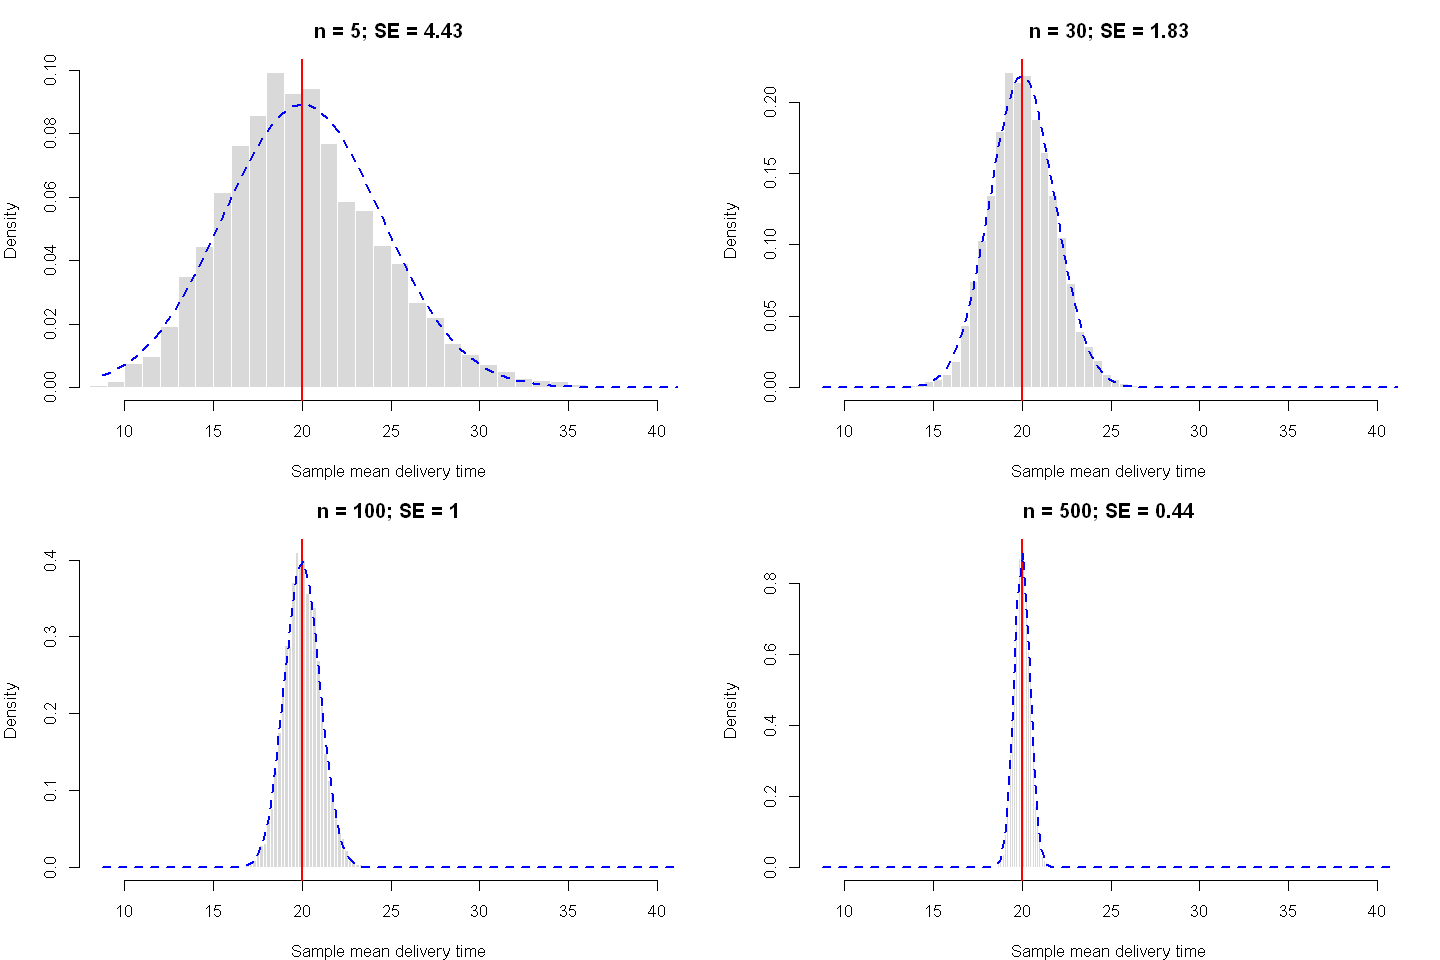

In [15]:
options(repr.plot.width = 12, repr.plot.height = 8)

# Use the same horizontal scale in every graph
common_xlim <- range(unlist(sampling_distributions))

par(mfrow = c(2, 2), mar = c(4, 4, 3, 1))

for (j in seq_along(sample_sizes)) {

  n <- sample_sizes[j]
  means_n <- sampling_distributions[[j]]

  # Standard error with a finite-population correction
  theoretical_se <- population_sd / sqrt(n) *
    sqrt((N - n) / (N - 1))

  hist(
    means_n,
    breaks = 40,
    probability = TRUE,
    xlim = common_xlim,
    main = paste0(
      "n = ", n,
      "; SE = ", round(sd(means_n), 2)
    ),
    xlab = "Sample mean delivery time",
    col = "grey85",
    border = "white"
  )

  # True population mean
  abline(
    v = population_mean,
    col = "red",
    lwd = 2
  )

  # Corresponding normal approximation
  curve(
    dnorm(
      x,
      mean = population_mean,
      sd = theoretical_se
    ),
    add = TRUE,
    col = "blue",
    lwd = 2,
    lty = 2
  )
}

par(mfrow = c(1, 1))

The figures illustrate three important results.

1. **The centre remains approximately unchanged.**  
   For every sample size, the sampling distribution is centred near the population mean of 20 minutes. Increasing the sample size does not systematically raise or lower the sample mean.

2. **The sampling distribution becomes narrower.**  
   Larger samples produce more precise estimates. Because

   $$
   SE(\bar Y)\approx\frac{\sigma}{\sqrt n},
$$

   increasing $n$ reduces the variability of the sample mean.

3. **The sampling distribution becomes more nearly normal.**  
   For $n=5$, some right-skewness inherited from the population may remain. For $n=30$, the distribution is already reasonably bell-shaped. For $n=100$ and $n=500$, it is highly concentrated and approximately normal.

